# Sección 3 : Selección de muestra para entrenamiento y pruebas de rendimiento de modelos.

## Sección 3.A : Importación de Librerías y Carga de Datos Procesados

En esta sección importamos todas las librerías necesarias para el modelado y cargamos el dataset final procesado que resultó del notebook de preprocesamiento. Esto incluye librerías para manipulación de datos (pandas, numpy), visualización (matplotlib, seaborn), algoritmos de machine learning (scikit-learn) y manejo de archivos (os).

El dataset cargado contiene las características finales después del feature engineering y codificación one-hot, listo para el entrenamiento de modelos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, 
                              precision_recall_curve, auc, accuracy_score, precision_score, 
                              recall_score, f1_score, matthews_corrcoef)
import joblib

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Crear directorio de reportes si no existe
directorio_actual = os.getcwd()
raiz_proyecto = os.path.dirname(directorio_actual)
os.makedirs(os.path.join(raiz_proyecto, 'E_reports'), exist_ok=True)
os.makedirs(os.path.join(raiz_proyecto, 'E_reports', 'figures'), exist_ok=True)

# Cargar datos finales procesados
ruta_datos = os.path.join(raiz_proyecto, 'A_data', '02_processed', 'processed_credit_card_data.csv')

print(f"Cargando datos desde: {ruta_datos}")
df = pd.read_csv(ruta_datos)
print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"📁 Directorios de reportes creados")
print(df.head())

Cargando datos desde: c:\Users\mbeni\Desktop\Portafolio_Projects\default_of_credit_card_clients\A_data\02_processed\processed_credit_card_data.csv
Dataset cargado: 30000 filas, 34 columnas
   LIMIT_BAL  AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  \
0      20000   24      2      2     -1     -1     -2     -2       3913   
1     120000   26     -1      2      0      0      0      2       2682   
2      90000   34      0      0      0      0      0      0      29239   
3      50000   37      0      0      0      0      0      0      46990   
4      50000   57     -1      0     -1      0      0      0       8617   

   BILL_AMT2  ...  SEX_MAN  SEX_WOMAN  EDUCATION_GRAD_SCHOOL  \
0       3102  ...        0          1                      0   
1       1725  ...        0          1                      0   
2      14027  ...        0          1                      0   
3      48233  ...        0          1                      0   
4       5670  ...        1          0         

## Sección 3.B : Preparación de Datos para Modelado

Esta sección es fundamental para preparar los datos antes del entrenamiento. Separamos las características (X) del target (y), analizamos la distribución de clases para confirmar el desbalance, dividimos el dataset en conjuntos de entrenamiento (80%) y prueba (20%) con estratificación para mantener la proporción de clases, y finalmente escalamos las características usando StandardScaler para normalizar los datos (media=0, desviación estándar=1).

El escalado es crucial para algoritmos como Regresión Logística y SVM, mientras que Random Forest es menos sensible pero no se ve afectado negativamente.

In [2]:
# Preparar datos para modelado
X = df.drop('default_payment_next_month', axis=1)
y = df['default_payment_next_month']

print(f"Distribución de clases: {y.value_counts()}")
print(f"Proporción de default: {y.mean():.2%}")

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set: {X_train.shape[0]} muestras")
print(f"Test set: {X_test.shape[0]} muestras")

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Distribución de clases: default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64
Proporción de default: 22.12%
Train set: 24000 muestras
Test set: 6000 muestras


## Sección 3.C : Definición y Entrenamiento de Modelos

En esta sección definimos tres algoritmos de clasificación diferentes: Regresión Logística (modelo lineal interpretable), Random Forest (método ensemble robusto) y SVM (clasificador basado en kernels). Cada modelo se entrena con los datos escalados de entrenamiento y se evalúa en el conjunto de prueba.

Calculamos métricas clave como ROC AUC (principal para datos desbalanceados), accuracy, precision, recall y F1-score. Los resultados se almacenan en un diccionario para facilitar la comparación posterior.

In [ ]:
# Definir modelos a comparar (ampliado a 12 modelos)
models = {
    # Modelos Lineales
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    
    # Árboles
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    
    # Ensemble - Bagging
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Extra Trees': ExtraTreesClassifier(random_state=42, n_estimators=100),
    
    # Ensemble - Boosting
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, verbosity=0, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, n_estimators=100, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, n_estimators=100, verbose=0),
    
    # Otros
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

# Entrenar modelos y almacenar resultados
results = {}
results_list = []

print("🚀 Entrenando 12 modelos de clasificación...")
print("="*100)

for name, model in models.items():
    print(f"\n🔹 {name}")
    start_time = datetime.now()
    
    # Entrenar modelo
    model.fit(X_train_scaled, y_train)
    
    # Predicciones
    y_pred_train = model.predict(X_train_scaled)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    elapsed_time = (datetime.now() - start_time).total_seconds()
    
    # Métricas
    results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'report': classification_report(y_test, y_pred, output_dict=True),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    # Guardar en lista para DataFrame
    results_list.append({
        'Model': name,
        'Train_Accuracy': accuracy_score(y_train, y_pred_train),
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_pred_proba),
        'Training_Time': elapsed_time
    })
    
    # Mostrar métricas
    print(f"  Train Acc: {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"  Test Acc:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC AUC:   {results[name]['roc_auc']:.4f}")
    print(f"  Time:      {elapsed_time:.2f}s")

print("\n✅ Entrenamiento de todos los modelos completado")

# Crear DataFrame de resultados
results_df = pd.DataFrame(results_list).sort_values('ROC_AUC', ascending=False)
results_df.to_csv(os.path.join(raiz_proyecto, 'E_reports', 'model_comparison_results.csv'), index=False)
print("\n✅ Resultados guardados en: reports/model_comparison_results.csv")

Entrenando Logistic Regression...
Logistic Regression - ROC AUC: 0.726
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.23      0.35      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

--------------------------------------------------
Entrenando Random Forest...
Random Forest - ROC AUC: 0.763
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.37      0.47      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.79      0.81      0.79      6000

--------------------------------------------------
Entrenando SVM...
SVM - ROC AUC: 0.714
              precision    recall  f1-score   support

           0       0

## Sección 3.D : Visualización de Matrices de Confusión

Las matrices de confusión muestran el rendimiento detallado de cada modelo, indicando los aciertos y errores de clasificación. Cada matriz muestra:
- Verdaderos Positivos (TP): Defaults correctamente identificados
- Verdaderos Negativos (TN): No-defaults correctamente identificados  
- Falsos Positivos (FP): No-defaults clasificados erróneamente como defaults
- Falsos Negativos (FN): Defaults no detectados

Esta visualización es crucial para entender los tipos de errores que comete cada modelo en un problema de clasificación binaria desbalanceada.

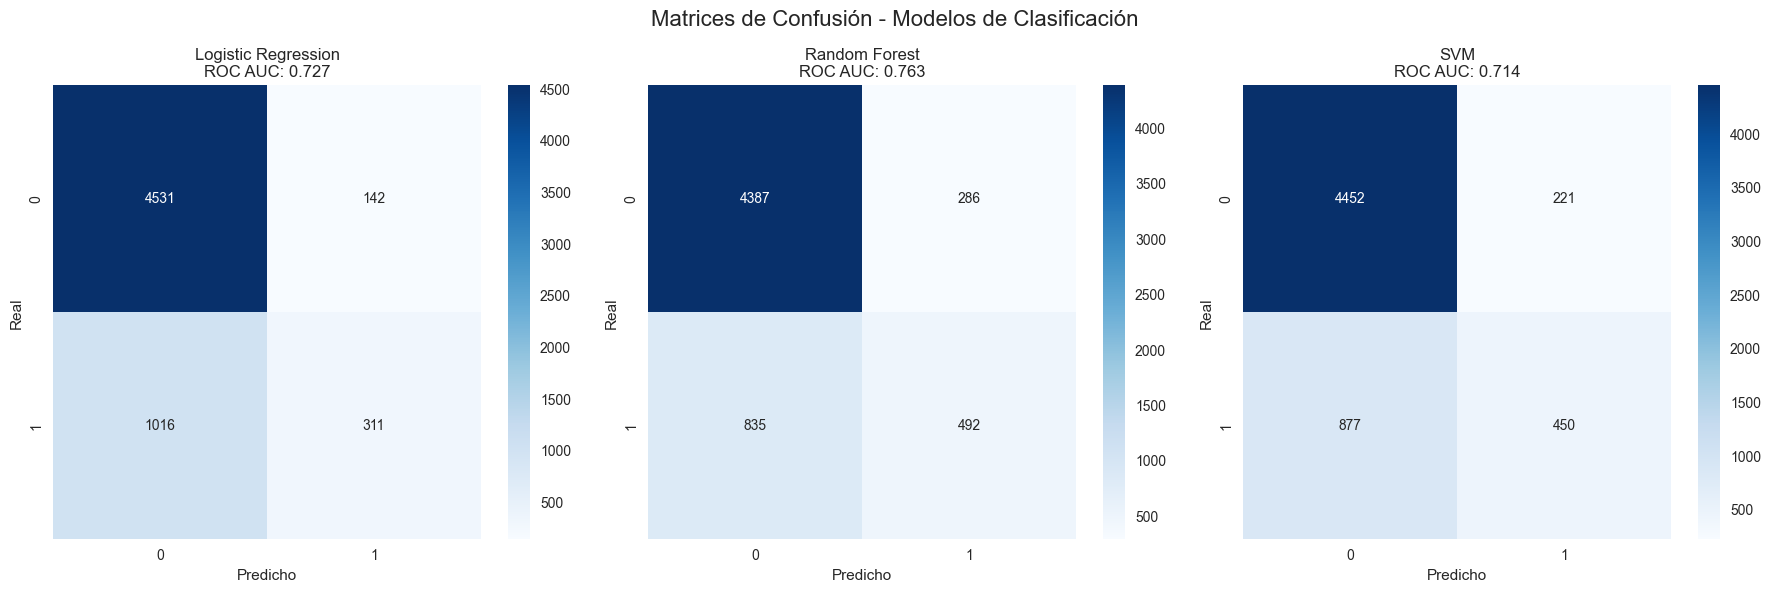

In [ ]:
# Gráficos de matrices de confusión (todas los modelos)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.ravel()

for i, (name, result) in enumerate(results.items()):
    cm = result['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    axes[i].set_title(f'{name}\nAUC: {result["roc_auc"]:.3f} | Sens: {sensitivity:.3f}', 
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicho', fontsize=10)
    axes[i].set_ylabel('Real', fontsize=10)

plt.suptitle('📊 Matrices de Confusión - Todos los Modelos', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(raiz_proyecto, 'E_reports', 'figures', '01_confusion_matrices.png'), 
            dpi=300, bbox_inches='tight')
print("✅ Figura guardada: reports/figures/01_confusion_matrices.png")
plt.show()

In [ ]:
# Comparación visual completa de métricas
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'Training_Time']
titles = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Training Time (s)']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    row = idx // 3
    col = idx % 3
    
    ax = axes[row, col]
    data = results_df.sort_values(metric, ascending=(metric != 'Training_Time'))
    
    bars = ax.barh(data['Model'], data[metric], color=color, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Score' if metric != 'Training_Time' else 'Seconds', fontsize=11)
    ax.set_title(f'{title} by Model', fontsize=13, fontweight='bold')
    
    if metric != 'Training_Time':
        ax.set_xlim([0, 1])
    
    ax.grid(axis='x', alpha=0.3)
    
    # Añadir valores
    for i, v in enumerate(data[metric]):
        if metric == 'Training_Time':
            ax.text(v + 0.5, i, f'{v:.1f}s', va='center', fontsize=9)
        else:
            ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('📊 Análisis Comparativo Completo - 12 Modelos', y=1.002, fontsize=16, fontweight='bold')
plt.savefig(os.path.join(raiz_proyecto, 'E_reports', 'figures', '02_model_comparison.png'), 
            dpi=300, bbox_inches='tight')
print("✅ Figura guardada: reports/figures/02_model_comparison.png")
plt.show()

## Sección 3.E : Curvas ROC y Análisis de Rendimiento

Las Curvas ROC (Receiver Operating Characteristic) grafican la Tasa de Verdaderos Positivos vs. Tasa de Falsos Positivos para diferentes umbrales de decisión. El Área Bajo la Curva (AUC) mide la capacidad del modelo para distinguir entre clases.

- AUC = 1.0: Clasificación perfecta
- AUC = 0.5: Clasificador aleatorio (línea diagonal)
- AUC cercano a 0: Clasificación invertida

Esta métrica es especialmente útil para datasets desbalanceados, ya que no depende de un umbral específico y evalúa el rendimiento general del modelo.

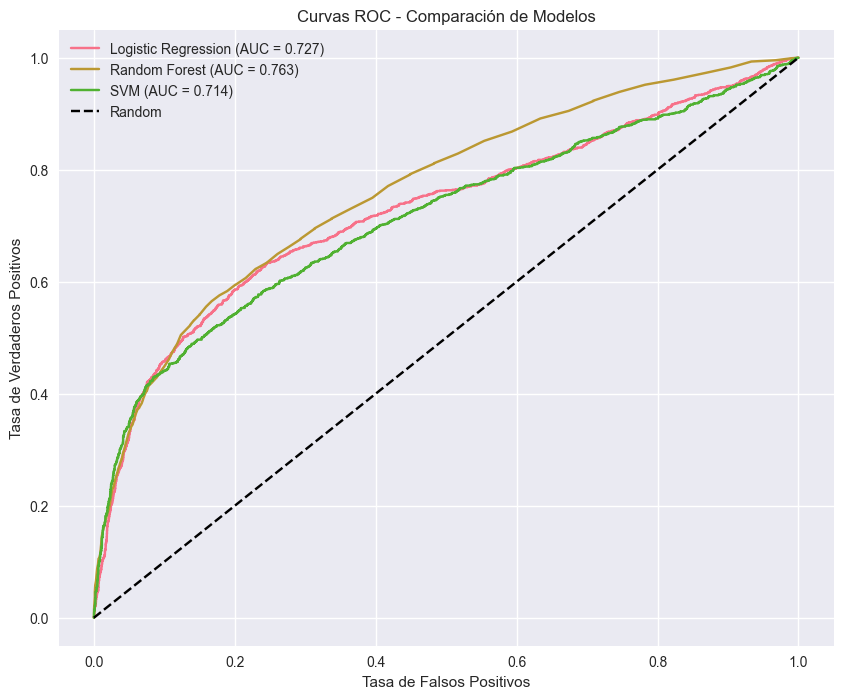

In [ ]:
# Curvas ROC para todos los modelos
plt.figure(figsize=(12, 10))

colors = plt.cm.tab20(np.linspace(0, 1, len(results)))

for (name, result), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.3f})', 
             lw=2, color=color)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('📈 Curvas ROC - Comparación de Todos los Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(raiz_proyecto, 'E_reports', 'figures', '03_roc_curves.png'), 
            dpi=300, bbox_inches='tight')
print("✅ Figura guardada: reports/figures/03_roc_curves.png")
plt.show()

In [ ]:
# Curvas Precision-Recall
plt.figure(figsize=(12, 10))

colors = plt.cm.tab20(np.linspace(0, 1, len(results)))
baseline = (y_test == 1).sum() / len(y_test)

for (name, result), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, result['probabilities'])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})', 
             lw=2, color=color)

plt.plot([0, 1], [baseline, baseline], 'k--', lw=2, 
         label=f'Baseline (Prevalence = {baseline:.3f})')
plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('📈 Curvas Precision-Recall - Comparación de Todos los Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(raiz_proyecto, 'E_reports', 'figures', '04_precision_recall_curves.png'), 
            dpi=300, bbox_inches='tight')
print("✅ Figura guardada: reports/figures/04_precision_recall_curves.png")
plt.show()

## Sección 3.F : Comparación Tabular y Visual de Métricas

Esta sección presenta una comparación cuantitativa completa del rendimiento de los tres modelos mediante:

1. **Tabla comparativa**: Muestra métricas clave para cada modelo
   - ROC AUC: Medida principal de discriminación
   - Accuracy: Porcentaje total de aciertos
   - Precision: De los predichos como defaults, cuántos lo son realmente
   - Recall: De todos los defaults reales, cuántos detectamos
   - F1-Score: Media armónica de precision y recall

2. **Gráficos de barras**: Visualización intuitiva de las diferencias entre modelos

Esta comparación permite seleccionar el modelo más adecuado según las necesidades del negocio (ej: maximizar recall para minimizar riesgos de default no detectados).

Comparación de Rendimiento de Modelos:


,Modelo,ROC AUC,Accuracy,Precision (Clase 1),Recall (Clase 1),F1-Score (Clase 1)
0,Logistic Regression,0.7265,0.8070,0.6865,0.2344,0.3494
1,Random Forest,0.7633,0.8132,0.6324,0.3708,0.4675
2,SVM,0.7138,0.8170,0.6706,0.3391,0.4505


C:\Users\mbeni\AppData\Local\Temp\ipykernel_14788\4150470460.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Modelo', y=metric, ax=ax, palette='viridis')
C:\Users\mbeni\AppData\Local\Temp\ipykernel_14788\4150470460.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Modelo', y=metric, ax=ax, palette='viridis')
C:\Users\mbeni\AppData\Local\Temp\ipykernel_14788\4150470460.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Modelo', y=metric, ax=ax, palette='viridis')
C:\Users\m

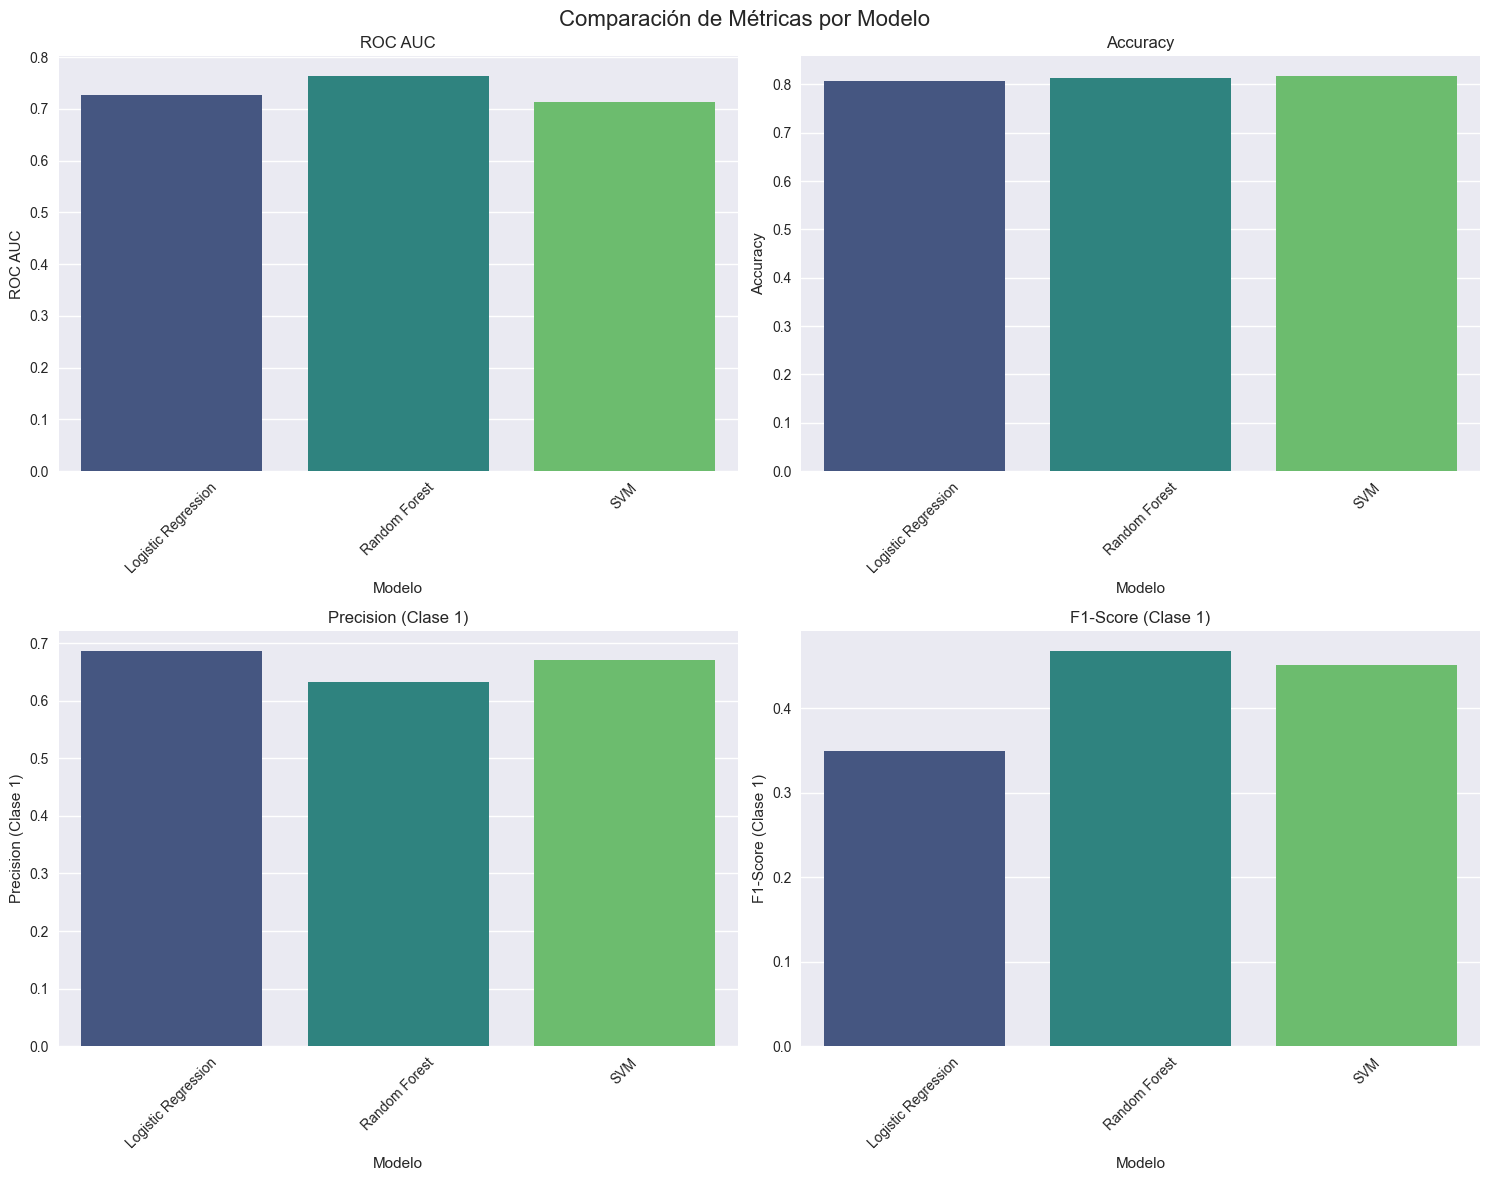

In [7]:
# Tabla comparativa de métricas
metrics_df = pd.DataFrame({
    'Modelo': list(results.keys()),
    'ROC AUC': [results[name]['roc_auc'] for name in results.keys()],
    'Accuracy': [results[name]['report']['accuracy'] for name in results.keys()],
    'Precision (Clase 1)': [results[name]['report']['1']['precision'] for name in results.keys()],
    'Recall (Clase 1)': [results[name]['report']['1']['recall'] for name in results.keys()],
    'F1-Score (Clase 1)': [results[name]['report']['1']['f1-score'] for name in results.keys()]
})

print("Comparación de Rendimiento de Modelos:")
display(metrics_df.round(4))

# Gráfico de barras para métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Comparación de Métricas por Modelo', fontsize=16)

metrics_to_plot = ['ROC AUC', 'Accuracy', 'Precision (Clase 1)', 'F1-Score (Clase 1)']
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    sns.barplot(data=metrics_df, x='Modelo', y=metric, ax=ax, palette='viridis')
    ax.set_title(f'{metric}')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Sección 3.G : Selección del Mejor Modelo y Persistencia

Basándonos en la métrica ROC AUC (más robusta para datos desbalanceados), seleccionamos automáticamente el mejor modelo entre los tres evaluados. Este modelo se guarda junto con el scaler utilizado para el preprocesamiento, permitiendo su uso posterior en producción o deployment.

Los archivos se almacenan en la carpeta D_models siguiendo la estructura organizada del proyecto, facilitando la integración con sistemas de producción o APIs.

In [ ]:
# Seleccionar el mejor modelo basado en ROC AUC
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['model']

print(f"🏆 El mejor modelo es: {best_model_name}")
print(f"   ROC AUC: {results[best_model_name]['roc_auc']:.4f}")

# Crear métricas detalladas
detailed_results = []
for name in results.keys():
    y_pred = results[name]['predictions']
    y_proba = results[name]['probabilities']
    cm = results[name]['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    
    detailed_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_Score': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'MCC': matthews_corrcoef(y_test, y_pred),
        'Specificity': tn / (tn + fp),
        'Sensitivity': tp / (tp + fn)
    })

detailed_df = pd.DataFrame(detailed_results).sort_values('ROC_AUC', ascending=False)
detailed_df.to_csv(os.path.join(raiz_proyecto, 'E_reports', 'detailed_metrics.csv'), index=False)
print("\n✅ Métricas detalladas guardadas: reports/detailed_metrics.csv")

# Guardar el mejor modelo
model_path = os.path.join(raiz_proyecto, 'D_models', 'best_model.pkl')
scaler_path = os.path.join(raiz_proyecto, 'D_models', 'scaler.pkl')
model_info_path = os.path.join(raiz_proyecto, 'D_models', 'model_info.pkl')

os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)
print(f"\n✅ Modelo guardado en: {model_path}")
print(f"✅ Scaler guardado en: {scaler_path}")

# Guardar información del modelo
model_info = {
    'model_name': best_model_name,
    'model_type': type(best_model).__name__,
    'test_accuracy': accuracy_score(y_test, results[best_model_name]['predictions']),
    'test_precision': precision_score(y_test, results[best_model_name]['predictions']),
    'test_recall': recall_score(y_test, results[best_model_name]['predictions']),
    'test_f1': f1_score(y_test, results[best_model_name]['predictions']),
    'test_roc_auc': results[best_model_name]['roc_auc'],
    'test_mcc': matthews_corrcoef(y_test, results[best_model_name]['predictions']),
    'feature_names': list(X.columns),
    'n_features': X.shape[1],
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

joblib.dump(model_info, model_info_path)
print(f"✅ Información del modelo guardada: {model_info_path}")

# Crear reporte de texto
report_path = os.path.join(raiz_proyecto, 'E_reports', 'model_training_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("📊 REPORTE DE ENTRENAMIENTO DE MODELO\n")
    f.write("Default of Credit Card Clients Dataset\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"📅 Fecha: {model_info['training_date']}\n")
    f.write(f"👤 Autor: Miguel Antonio Benítez González\n\n")
    
    f.write(f"🏆 MEJOR MODELO: {best_model_name}\n")
    f.write(f"   ROC AUC: {model_info['test_roc_auc']:.4f}\n")
    f.write(f"   F1-Score: {model_info['test_f1']:.4f}\n\n")
    
    f.write(f"📊 MÉTRICAS:\n")
    f.write(f"   Accuracy:  {model_info['test_accuracy']:.4f}\n")
    f.write(f"   Precision: {model_info['test_precision']:.4f}\n")
    f.write(f"   Recall:    {model_info['test_recall']:.4f}\n")
    f.write(f"   MCC:       {model_info['test_mcc']:.4f}\n\n")
    
    f.write(f"📁 ARCHIVOS GENERADOS:\n")
    f.write(f"   • models/best_model.pkl\n")
    f.write(f"   • models/scaler.pkl\n")
    f.write(f"   • reports/model_comparison_results.csv\n")
    f.write(f"   • reports/detailed_metrics.csv\n")
    f.write(f"   • reports/figures/ (4 gráficas)\n\n")
    
    f.write("="*80 + "\n")
    f.write("✅ ENTRENAMIENTO COMPLETADO\n")
    f.write("="*80 + "\n")

print(f"✅ Reporte guardado: {report_path}")

El mejor modelo es: Random Forest con ROC AUC de 0.7633
Modelo guardado en: c:\Users\mbeni\Desktop\Portafolio_Projects\default_of_credit_card_clients\D_models\best_model.pkl
Scaler guardado en: c:\Users\mbeni\Desktop\Portafolio_Projects\default_of_credit_card_clients\D_models\scaler.pkl
